# TP2 (a completer) : Arbre de decision — *Pima Diabetes*

Remplacez chaque `...` et chaque `# TODO`. Le corrige
(`../notebooks/TP2_arbre_decision.ipynb`) applique la **meme demarche sur un
AUTRE dataset (Breast Cancer)** : la structure est identique, seules les donnees
et les colonnes changent : a vous d'adapter.

**Objectif.** Predire si une patiente est **diabetique** avec un arbre
**interpretable**, et evaluer en privilegiant le **rappel sur les cas diabetiques**.

In [1]:
# Cellule fournie : a executer telle quelle.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAVY, ACCENT, GRAY = "#16284D", "#0EA5E9", "#5B6679"
RED = "#C0504D"
PALETTE = [ACCENT, NAVY, "#F79646", "#3FA45B", RED]
plt.rcParams.update({
    "figure.figsize": (7, 4.5), "font.size": 12,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold",
    "axes.edgecolor": GRAY, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 120)
print("Environnement pret.")

Environnement pret.


## Etape 0 : charger les donnees (fournie)

In [2]:
from sklearn.datasets import fetch_openml
ds = fetch_openml(name="diabetes", version=1, as_frame=True)   # telecharge une fois puis cache
X = ds.data                                  # 8 mesures medicales (preg, plas, pres, ...)
y = (ds.target == "tested_positive").astype(int)
CLASSES = ["non_diabetique", "diabetique"]   # 0 = negatif, 1 = positif
print(X.shape, CLASSES)

(768, 8) ['non_diabetique', 'diabetique']


## 1. Exploration
**Consigne.** Affichez la repartition des classes (combien de diabetiques / non).

In [3]:
# TODO : repartition de y (indice : value_counts + map vers CLASSES)
repartition = y.map({0: CLASSES[0], 1: CLASSES[1]}).value_counts()
print(repartition)

class
non_diabetique    500
diabetique        268
Name: count, dtype: int64


## 2. Modelisation
**Consigne.** Separez en train/test (25% test, `stratify=y`, `random_state=42`),
puis entrainez un `DecisionTreeClassifier` (`max_depth=3`, `min_samples_leaf=10`).

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

arbre = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=42)
arbre.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

## 3. Evaluation
**Consigne.** Affichez l'accuracy train et test, le `classification_report`
(avec `target_names=CLASSES`) et la **matrice de confusion**. Commentez le
**rappel** de la classe `diabetique`.

Accuracy train : 0.783
Accuracy test  : 0.714
                precision    recall  f1-score   support

non_diabetique      0.750     0.840     0.792       125
    diabetique      0.615     0.478     0.538        67

      accuracy                          0.714       192
     macro avg      0.683     0.659     0.665       192
  weighted avg      0.703     0.714     0.704       192



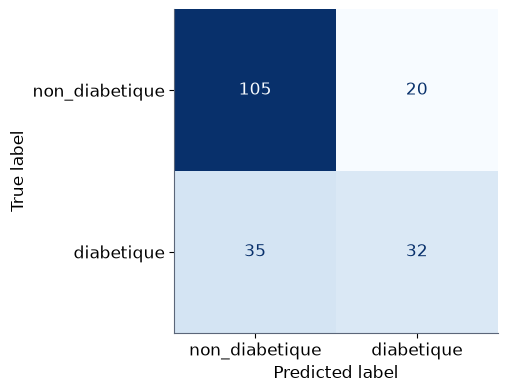

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# TODO : accuracy train / test
print(f"Accuracy train : {arbre.score(X_train, y_train):.3f}")
print(f"Accuracy test  : {arbre.score(X_test, y_test):.3f}")
y_pred = arbre.predict(X_test)
# TODO : afficher classification_report
print(classification_report(y_test, y_pred, target_names=CLASSES, digits=3))
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4.2))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
plt.show()

## 4. Visualisation
**Consigne.** Tracez l'arbre (`plot_tree`) puis l'**importance des variables**
(barres horizontales des `feature_importances_` non nulles).

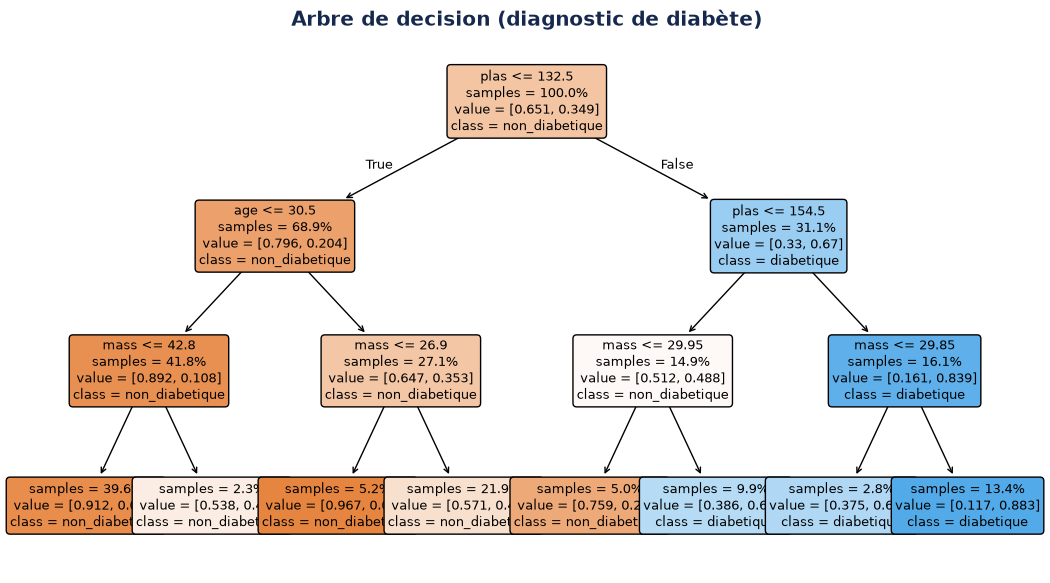

In [6]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(13, 7))
# TODO : plot_tree(arbre, feature_names=..., class_names=CLASSES, filled=True, ...)
plot_tree(arbre, feature_names=list(X.columns), class_names=CLASSES, filled=True,
          rounded=True, fontsize=9, impurity=False, proportion=True, ax=ax)
ax.set_title("Arbre de decision (diagnostic de diabète)")
plt.show()

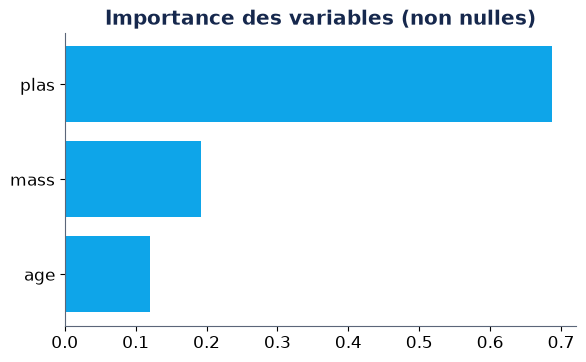

In [7]:
imp = pd.Series(arbre.feature_importances_, index=X.columns)
imp = imp[imp > 0].sort_values()
# TODO : barh de imp
fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.barh(imp.index, imp.values, color=ACCENT)
ax.set_title("Importance des variables (non nulles)")
plt.show()

## 5. Prise de decision
**Consigne.** Sur 5 cas du test, affichez diagnostic reel, predit et
`predict_proba` de la classe diabetique.

In [8]:
ech = X_test.head(5)
# TODO : pred et proba, puis DataFrame comparatif
pred = arbre.predict(ech)
proba = arbre.predict_proba(ech)[:, 1]
pd.DataFrame({
    "reel": [CLASSES[v] for v in y_test.head(5)],
    "predit": [CLASSES[p] for p in pred],
    "proba_diabetique": proba.round(2),
})

,reel,predit,proba_diabetique
0,diabetique,non_diabetique,0.43
1,non_diabetique,non_diabetique,0.09
2,non_diabetique,non_diabetique,0.09
3,diabetique,diabetique,0.61
4,diabetique,diabetique,0.88


Accuracy train : 0.790
Accuracy test  : 0.734
                precision    recall  f1-score   support

non_diabetique      0.750     0.888     0.813       125
    diabetique      0.682     0.448     0.541        67

      accuracy                          0.734       192
     macro avg      0.716     0.668     0.677       192
  weighted avg      0.726     0.734     0.718       192



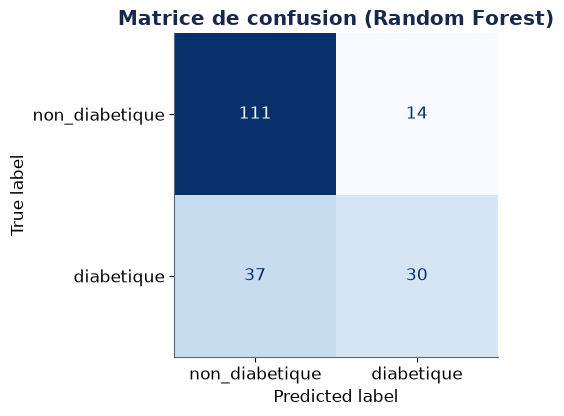

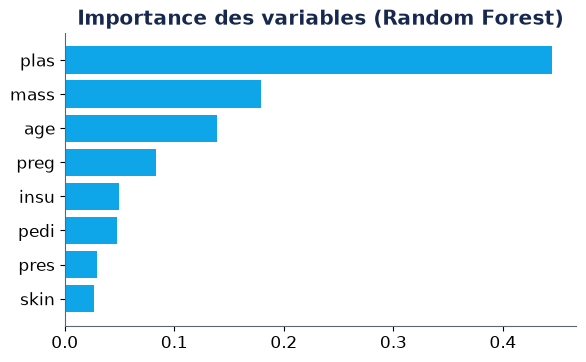

plas    0.445
mass    0.179
age     0.139
preg    0.083
insu    0.050
pedi    0.048
pres    0.030
skin    0.027
dtype: float64


In [9]:
from sklearn.ensemble import RandomForestClassifier

foret = RandomForestClassifier(n_estimators=100, max_depth=3, min_samples_leaf=10, random_state=42)
foret.fit(X_train, y_train)

print(f"Accuracy train : {foret.score(X_train, y_train):.3f}")
print(f"Accuracy test  : {foret.score(X_test, y_test):.3f}")

y_pred_rf = foret.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=CLASSES, digits=3))

cm_foret = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(5, 4.2))
ConfusionMatrixDisplay(cm_foret, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matrice de confusion (Random Forest)")
plt.show()

imp_foret = pd.Series(foret.feature_importances_, index=X.columns)
imp_foret = imp_foret[imp_foret > 0].sort_values()
fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.barh(imp_foret.index, imp_foret.values, color=ACCENT)
ax.set_title("Importance des variables (Random Forest)")
plt.show()

print(imp_foret.sort_values(ascending=False).round(3))

## A rendre
- Accuracy test + lecture de la matrice de confusion.
- Le rappel sur `diabetique` et pourquoi il est prioritaire ici.
- Les 2-3 variables les plus determinantes.

**Bonus.** Faites varier `max_depth` (2, 3, 6, None) : ou commence le surapprentissage ?